# NB01d — VHR Request AOI Export

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `01d_bda_AOI_Export_v2.ipynb` |
| **Version** | v2 |
| **Pipeline position** | Utility. Standalone export for Airbus Pleiades data request. |
| **Last validated** | 2026-04-XX |

## Narrative

Single-purpose utility notebook. Combines all 50 city bounding boxes from
`boundary.geojson` (created by NB01a/NB01b Cell 8) into one ESRI Shapefile
for submission with the Airbus Pleiades academic research data request.

The Shapefile carries per-city attributes (city_name, tier, battle_start,
battle_stop, oblast) so the Airbus team can assess coverage and prioritize
acquisitions. Pleiades 1A/1B is preferred over Neo for pre-conflict archive depth.

This notebook does not feed into the main processing pipeline. It is a one-shot
export that was run once to generate the request file.

## Scientific Rationale

Pleiades VHR imagery (0.5m) would enable building-level validation masks independent
of UNOSAT labels. This addresses the thesis limitation that UNOSAT is incomplete
(Aimaiti et al. 2022) by providing ground truth from a different sensor and
assessment methodology. The request covers all 50 cities to maximize validation
coverage across tiers.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `boundary.geojson` per city | NB01a/NB01b Cell 8 | GeoJSON (50 cities) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| `_request_aois.shp` (+.dbf/.prj/.shx/.cpg) | `DATA_ROOT/` | Airbus Pleiades request (external) |

## Prerequisites
- NB01a/NB01b Cell 8 must have run (boundary.geojson per city)

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 4 | Load global_setup | Config |
| 2 | Cell 1 | Config (OUTPUT_SHP path) | Config |
| 3 | Cell 2 | Combine all bboxes into Shapefile | **Core** |
| 4 | Cell 3 | Verify output (schema, CRS, bounds) | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — VHR Validation (if acquired) | All | Pleiades request methodology |

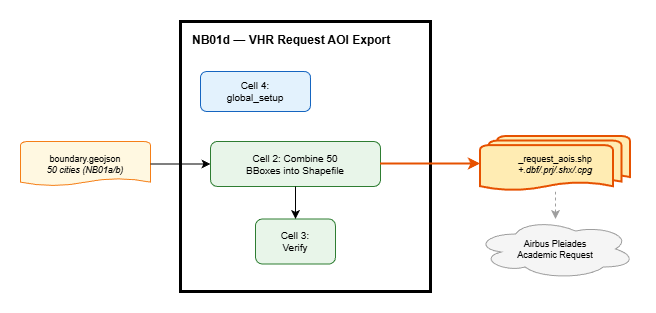

# NB01d:  VHR Request - AOI Export

Combines all 50 city bounding boxes from `boundary.geojson` into a single Shapefile for the  Pleiades academic research data request.

**Output:** `_request_aois.shp` with attributes: city_name, tier, battle_start, battle_stop, oblast

In [1]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-03-21 10:47:27
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /content/masterthesis_local/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 43 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:418: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     11204.9/14901.9 GB (3697.0 GB free)
  GDrive (F:)     997.0/3726.0 GB (2729.0 GB free)
  Local data      11204.9/14901.9 GB (3697.0 GB free)
  Data stack      11204.9/14901.9 GB (3697.0 GB free)
  WSL ext4        59.4/1006.9 GB (896.2 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 43, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_

In [2]:
# =============================================================================
# NB01d CELL 1: CONFIG
# =============================================================================
from pathlib import Path
import json


OUTPUT_SHP = DATA_ROOT / "_request_aois.shp"

print(f"CITIES_DIR: {CITIES_DIR}")
print(f"OUTPUT_SHP: {OUTPUT_SHP}")
print(f"Cities found: {len([d for d in CITIES_DIR.iterdir() if d.is_dir() and (d / 'boundary.geojson').exists()])}")

CITIES_DIR: /content/drive_f/masterthesis/data/cities
OUTPUT_SHP: /content/drive_f/masterthesis/data/_request_aois.shp
Cities found: 50


In [3]:
# =============================================================================
# NB01d CELL 2: COMBINE ALL CITY BBOXES INTO ONE SHAPEFILE
# =============================================================================
from shapely.geometry import shape, box, mapping
import fiona
from fiona.crs import from_epsg

schema = {
    "geometry": "Polygon",
    "properties": {
        "city_name": "str",
        "tier": "int",
        "battle_start": "str",
        "battle_stop": "str",
        "oblast": "str",
    },
}

records = []

for city_dir in sorted(CITIES_DIR.iterdir()):
    if not city_dir.is_dir():
        continue
    boundary_file = city_dir / "boundary.geojson"
    if not boundary_file.exists():
        continue

    with open(boundary_file, "r") as f:
        gj = json.load(f)

    feat = gj["features"][0]
    props = feat["properties"]
    geom = shape(feat["geometry"])

    # bounding box polygon from city geometry
    minx, miny, maxx, maxy = geom.bounds
    bbox_poly = box(minx, miny, maxx, maxy)

    records.append({
        "geometry": mapping(bbox_poly),
        "properties": {
            "city_name": props.get("city_name", city_dir.name),
            "tier": int(props.get("tier", 0)),
            "battle_start": str(props.get("battle_start", "")),
            "battle_stop": str(props.get("battle_stop", "")),
            "oblast": str(props.get("oblast", "")),
        },
    })

with fiona.open(OUTPUT_SHP, "w", driver="ESRI Shapefile", crs=from_epsg(4326), schema=schema) as dst:
    for rec in records:
        dst.write(rec)

print(f"Written {len(records)} city bounding boxes to {OUTPUT_SHP}")
print()
for r in records:
    p = r["properties"]
    print(f"  [T{p['tier']}] {p['city_name']:25s} | {p['oblast']:15s} | {p['battle_start']} - {p['battle_stop']}")

Written 50 city bounding boxes to /content/drive_f/masterthesis/data/_request_aois.shp

  [T0] Avdiivka                  | Donetsk         | None - None
  [T0] Bakhmut                   | Donetsk         | None - None
  [T2] Balakliia                 | Kharkiv         | None - None
  [T2] Borodyanka                | Kyiv            | None - None
  [T2] Bucha                     | Kyiv            | None - None
  [T1] Chasiv Yar                | Donetsk         | None - None
  [T2] Chernihiv                 | Chernihiv       | None - None
  [T2] Chornobaivka              | Kherson         | None - None
  [T2] Chuhuiv                   | Kharkiv         | None - None
  [T2] Dmytrivka                 | Kyiv            | None - None
  [T3] Dnipro                    | Dnipropetrovsk  | None - None
  [T1] Hirske                    | Luhansk         | None - None
  [T2] Hostomel                  | Kyiv            | None - None
  [T2] Huliaipole                | Zaporizhzhia    | None - None
  

In [4]:
# =============================================================================
# NB01d CELL 3: VERIFY OUTPUT
# =============================================================================
import fiona

with fiona.open(OUTPUT_SHP, "r") as src:
    print(f"Driver: {src.driver}")
    print(f"CRS: {src.crs}")
    print(f"Features: {len(src)}")
    print(f"Schema: {src.schema}")
    print(f"Bounds: {src.bounds}")

# list output sidecar files
for p in sorted(OUTPUT_SHP.parent.glob(OUTPUT_SHP.stem + ".*")):
    print(f"  {p.name:40s} {p.stat().st_size:>10,} bytes")

Driver: ESRI Shapefile
CRS: EPSG:4326
Features: 50
Schema: {'properties': {'city_name': 'str:80', 'tier': 'int:18', 'battle_sta': 'str:80', 'battle_sto': 'str:80', 'oblast': 'str:80'}, 'geometry': 'Polygon'}
Bounds: (23.91573099900006, 46.34309614600005, 38.79965746100004, 51.55475772600005)
  _request_aois.cpg                                10 bytes
  _request_aois.dbf                            17,144 bytes
  _request_aois.prj                               145 bytes
  _request_aois.shp                             6,900 bytes
  _request_aois.shx                               500 bytes
